Imports

In [ ]:
import numpy as np
from scipy.stats import median_test
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Dataset from Kaggle [Polycystic ovary syndrome (PCOS)](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos)

In [ ]:
df = pd.read_excel('PCOS_data_without_infertility.xlsx', sheet_name='Full_new')


In [ ]:
#only including relevant variables
new_df = df[['PCOS (Y/N)','Weight (Kg)', 'BMI','FSH/LH', 'FSH(mIU/mL)', 'LH(mIU/mL)']]

In [ ]:
#filtering to make a variable of people with PCOS
pcos = new_df[new_df['PCOS (Y/N)'].isin([1])]

In [ ]:
#filtering to make a variable of people without PCOS
no_pcos = new_df[new_df['PCOS (Y/N)'].isin([0])]

In [ ]:
#This variable includes people with PCOS and are underweight
p1 = new_df[new_df['PCOS (Y/N)'].isin([1])]
p1 = p1[p1['BMI'] <= 19]


In [ ]:
#This variable includes people with PCOS and are normal weight
p2 = new_df[new_df['PCOS (Y/N)'].isin([1])]
p2 = p2[(p2['BMI'] >= 19) & (p2['BMI'] <= 25)]


In [ ]:
#This variable includes people with PCOS and are overweight
p3 = new_df[new_df['PCOS (Y/N)'].isin([1])]
# Drop rows where 'BMI' is less than 25
p3 = p3[(p3['BMI'] >= 25)]

p3.dropna()

,PCOS (Y/N),Weight (Kg),BMI,FSH/LH,FSH(mIU/mL),LH(mIU/mL)
2,1,68.8,25.270891,6.295455,5.54,0.88
12,1,74.0,32.029086,1.324503,2.00,1.51
19,1,85.0,31.221304,2.333333,1.89,0.81
24,1,63.0,25.236340,6.000000,5.34,0.89
26,1,76.0,29.687500,2.223022,6.18,2.78
...,...,...,...,...,...,...
489,1,63.0,30.808352,3.029915,7.09,2.34
495,1,64.0,26.638918,4.449612,5.74,1.29
512,1,72.0,26.446281,3.736842,2.13,0.57
523,1,60.0,26.666667,5.710000,5.71,1.00


In [ ]:
#This variable includes people without PCOS and are underweight
n1 = new_df[new_df['PCOS (Y/N)'].isin([0])]
n1 = n1[n1['BMI'] <= 19]

In [ ]:
#This variable includes people without PCOS and are normal weight
n2 = new_df[new_df['PCOS (Y/N)'].isin([0])]
n2 = n2[(n2['BMI'] >= 19) & (n2['BMI'] <= 25)]


In [ ]:
#This variable includes people without PCOS and are overweight

n3 = new_df[new_df['PCOS (Y/N)'].isin([0])]
# Drop rows where 'BMI' is less than 25
n3 = n3[(n3['BMI'] >= 25)]

In [ ]:
p2_filtered = p2[p2['LH(mIU/mL)'] <= 20]

In [ ]:
print("Unique values in 'FSH/LH' column of p3 before filtering:")
print(p3['FSH/LH'].unique())
values_to_drop = [327, 61.875, 21.33333333]
filtered_p3 = p3[~p3['FSH/LH'].isin(values_to_drop)]
print("Unique values in 'FSH/LH' column of p3 after filtering:")
print(filtered_p3['FSH/LH'].unique())

Unique values in 'FSH/LH' column of p3 before filtering:
[  6.29545455   1.32450331   2.33333333   6.           2.22302158
   0.77314815  21.51851852   9.73333333   1.91769547   1.76923077
   4.15810277   2.35416667   1.32482599   1.01970443   0.83561644
   0.5959596    1.11418685   0.95251397   1.95718654   7.275
   1.36203523   0.80363636   5.07761194   1.02040816   7.11363636
   0.85034014   1.62454874   2.86335404  61.875        1.61290323
   3.55882353   6.48967552   4.17721519   2.65         7.45238095
   0.4352518    9.58823529   1.76296296   2.83428571   2.09615385
   2.83673469   3.18         2.83185841   1.64171123   0.69044586
 327.           7.52         1.125        1.06224066   2.5
   1.84738956   1.3559322    2.67073171   1.78723404   5.6407767
   0.48174157   2.45323741   3.1981982    0.70923379   1.47835498
   0.90240811   1.81518152  21.33333333   1.38034188   0.89719626
   2.18681319   5.59322034   2.325        0.86046512   5.58181818
   0.65972222   3.7745098    1.6

In [ ]:
threshold_FSH_LH = 20
threshold_FSH = 20

filtered_n2 = n2[(n2['FSH/LH'] <= threshold_FSH_LH) &
                 (n2['FSH(mIU/mL)'] <= threshold_FSH)]

print(filtered_n2)

     PCOS (Y/N)  Weight (Kg)        BMI    FSH/LH  FSH(mIU/mL)  LH(mIU/mL)
0             0         44.6  19.304017  2.160326         7.95        3.68
1             0         65.0  24.921163  6.174312         6.73        1.09
4             0         52.0  20.060954  4.422222         3.98        0.90
7             0         58.5  23.139907  1.583062         4.86        3.07
9             0         52.0  23.111111  1.854305         2.80        1.51
..          ...          ...        ...       ...          ...         ...
530           0         61.0  24.435187  3.657480         9.29        2.54
532           0         56.0  22.292122  2.017647        10.29        5.10
534           0         48.0  19.107533  0.398721         3.74        9.38
538           0         54.0  23.372576  4.302158        11.96        2.78
539           0         50.0  22.222222  1.016166         4.40        4.33

[197 rows x 6 columns]


Boxplot

---



In [ ]:

sns.set_palette("RdPu")

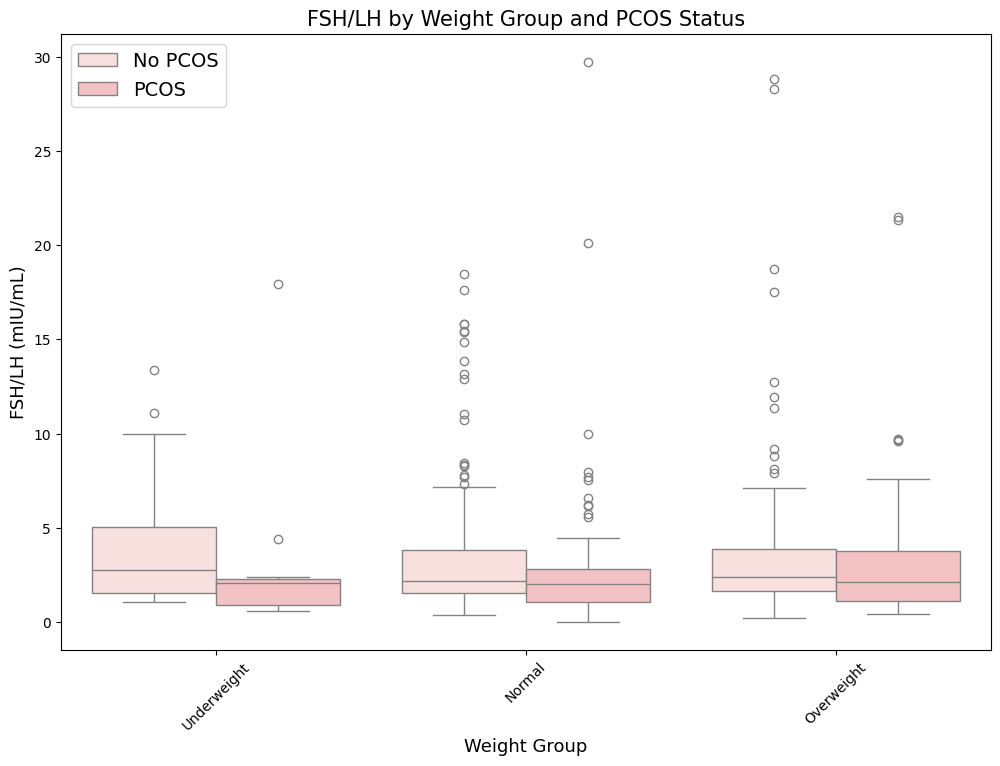

In [ ]:
#FH/LH box plot
combined_data = pd.concat([p1.assign(Weight_Class='Underweight PCOS'),
                           p2.assign(Weight_Class='Normal PCOS'),
                           filtered_p3.assign(Weight_Class='Overweight PCOS'),
                           n1.assign(Weight_Class='Underweight No-PCOS'),
                           filtered_n2.assign(Weight_Class='Normal No-PCOS'),
                           n3.assign(Weight_Class='Overweight No-PCOS')])

combined_data.reset_index(drop=True, inplace=True)


weight_class_mapping = {
    'Underweight PCOS': 'Underweight',
    'Underweight No-PCOS': 'Underweight',
    'Normal PCOS': 'Normal',
    'Normal No-PCOS': 'Normal',
    'Overweight PCOS': 'Overweight',
    'Overweight No-PCOS': 'Overweight'
}

combined_data['Weight_Group'] = combined_data['Weight_Class'].map(weight_class_mapping)

plt.figure(figsize=(12, 8))
sns.boxplot(x="Weight_Group", y="FSH/LH", hue="PCOS (Y/N)", data=combined_data)
plt.title('FSH/LH by Weight Group and PCOS Status', fontsize=15)
plt.xlabel('Weight Group', fontsize="13")
plt.ylabel('FSH/LH (mIU/mL)', fontsize="13")
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['No PCOS', 'PCOS']
plt.legend(handles, labels, fontsize="14", loc='upper left')
plt.xticks(rotation=45)
plt.show()


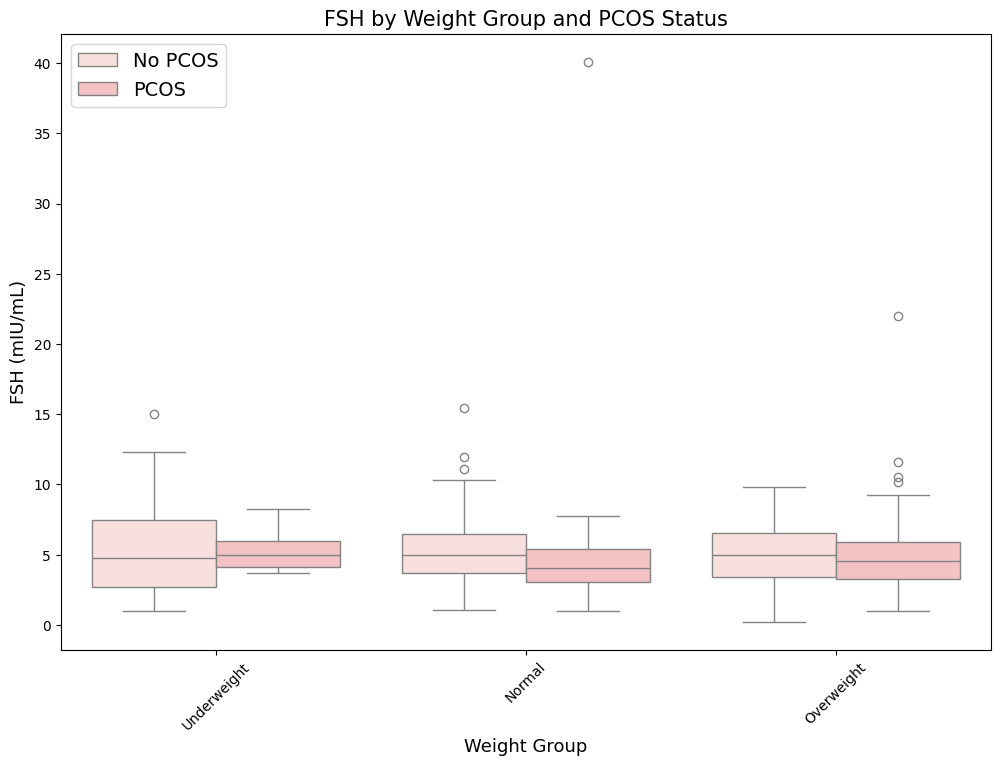

In [ ]:
#FH boxplots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined_data = pd.concat([p1.assign(Weight_Class='Underweight PCOS'),
                           p2.assign(Weight_Class='Normal PCOS'),
                           filtered_p3.assign(Weight_Class='Overweight PCOS'),
                           n1.assign(Weight_Class='Underweight No-PCOS'),
                           filtered_n2.assign(Weight_Class='Normal No-PCOS'),
                           n3.assign(Weight_Class='Overweight No-PCOS')])

combined_data.reset_index(drop=True, inplace=True)


weight_class_mapping = {
    'Underweight PCOS': 'Underweight',
    'Underweight No-PCOS': 'Underweight',
    'Normal PCOS': 'Normal',
    'Normal No-PCOS': 'Normal',
    'Overweight PCOS': 'Overweight',
    'Overweight No-PCOS': 'Overweight'
}

combined_data['Weight_Group'] = combined_data['Weight_Class'].map(weight_class_mapping)



plt.figure(figsize=(12, 8))
sns.boxplot(x="Weight_Group", y="FSH(mIU/mL)", hue="PCOS (Y/N)", data=combined_data)
plt.title('FSH by Weight Group and PCOS Status', fontsize=15)
plt.xlabel('Weight Group', fontsize="13")
plt.ylabel('FSH (mIU/mL)', fontsize="13")
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['No PCOS', 'PCOS']
plt.legend(handles, labels, fontsize="14", loc='upper left')
plt.xticks(rotation=45)
plt.show()

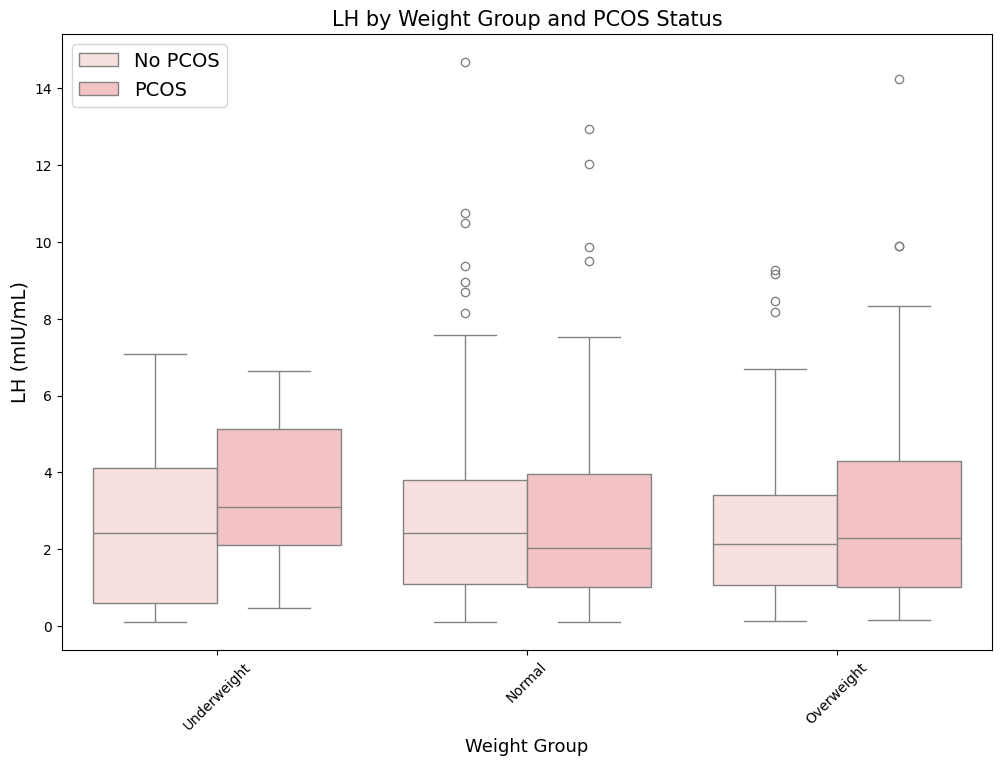

In [ ]:
#LH boxplot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined_data = pd.concat([p1.assign(Weight_Class='Underweight PCOS'),
                           p2_filtered.assign(Weight_Class='Normal PCOS'),
                           filtered_p3.assign(Weight_Class='Overweight PCOS'),
                           n1.assign(Weight_Class='Underweight No-PCOS'),
                           filtered_n2.assign(Weight_Class='Normal No-PCOS'),
                           n3.assign(Weight_Class='Overweight No-PCOS')])

combined_data.reset_index(drop=True, inplace=True)


weight_class_mapping = {
    'Underweight PCOS': 'Underweight',
    'Underweight No-PCOS': 'Underweight',
    'Normal PCOS': 'Normal',
    'Normal No-PCOS': 'Normal',
    'Overweight PCOS': 'Overweight',
    'Overweight No-PCOS': 'Overweight'
}

combined_data['Weight_Group'] = combined_data['Weight_Class'].map(weight_class_mapping)

plt.figure(figsize=(12, 8))
sns.boxplot(x="Weight_Group", y="LH(mIU/mL)", hue="PCOS (Y/N)", data=combined_data)
plt.title('LH by Weight Group and PCOS Status', fontsize=15)
plt.xlabel('Weight Group', fontsize="13")
plt.ylabel('LH (mIU/mL)', fontsize="14")
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['No PCOS', 'PCOS']
plt.legend(handles, labels, fontsize="14", loc='upper left')
plt.xticks(rotation=45)
plt.show()

In [ ]:
pcos = pd.DataFrame({'BMI': np.random.normal(loc=10, scale=2, size=50)})
no_pcos = pd.DataFrame({'BMI': np.random.normal(loc=12, scale=2, size=50)})

# Extract the values column from each DataFrame
group1 = pcos['BMI'].to_numpy()
group2 = no_pcos['BMI'].to_numpy()

statistic, p_value, medians, table = median_test(group1, group2)

print("Mood's median test statistic:", statistic)
print("P-value:", p_value)
print("Medians:", medians)
print("Contingency table:")
print(table)

Mood's median test statistic: 11.56
P-value: 0.0006738585313537617
Medians: 11.386206637132839
Contingency table:
[[16 34]
 [34 16]]


In [ ]:
n1 = pd.DataFrame({'FSH/LH': np.random.normal(loc=10, scale=2, size=50)})
n2 = pd.DataFrame({'FSH/LH': np.random.normal(loc=12, scale=2, size=50)})
n3 = pd.DataFrame({'FSH/LH': np.random.normal(loc=15, scale=3, size=50)})

# Extract the values column from each DataFrame
group1 = n1['FSH/LH'].to_numpy()
group2 = n2['FSH/LH'].to_numpy()
group3 = n3['FSH/LH'].to_numpy()

statistic, p_value, medians, table = median_test(group1, group2, group3)

print("Mood's median test statistic:", statistic)
print("P-value:", p_value)
print("Medians:", medians)
print("Contingency table:")
print(table)

Mood's median test statistic: 38.56
P-value: 4.234502454176727e-09
Medians: 12.623303711563068
Contingency table:
[[ 9 26 40]
 [41 24 10]]


In [ ]:
p1 = pd.DataFrame({'FSH/LH': np.random.normal(loc=10, scale=2, size=50)})
p2 = pd.DataFrame({'FSH/LH': np.random.normal(loc=12, scale=2, size=50)})
p3 = pd.DataFrame({'FSH/LH': np.random.normal(loc=15, scale=3, size=50)})

# Extract the values column from each DataFrame
group1 = p1['FSH/LH'].to_numpy()
group2 = p2['FSH/LH'].to_numpy()
group3 = p3['FSH/LH'].to_numpy()

statistic, p_value, medians, table = median_test(group1, group2, group3)

print("Mood's median test statistic:", statistic)
print("P-value:", p_value)
print("Medians:", medians)
print("Contingency table:")
print(table)

Mood's median test statistic: 42.88000000000001
P-value: 4.883445080639007e-10
Medians: 11.948157482326227
Contingency table:
[[ 7 29 39]
 [43 21 11]]
